In [1]:
import matplotlib.pylab as plt
import numpy as np

# Constants
a, b = -10.707508204773282, 1230.4499787903817  # for fitting TDC reading to core voltage
plots_dir = "final-plots"

In [ ]:
def pretty_plot_tdc_trace(trace: np.ndarray) -> None:
    # Format data
    y = (a*trace + b) / 1000.0
    x = np.arange(0, trace.shape[0]) * (1/(25e6*1.843))

    # Set up figure
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.plot(x*1e6, y)
    ax.set_ylabel("Measured Core Voltage (V)")
    ax.set_xlabel("Time (\u03BCs)")
    ax.set_title("")
    ...

# BitCrusher vs PicoEMP TDC comparison

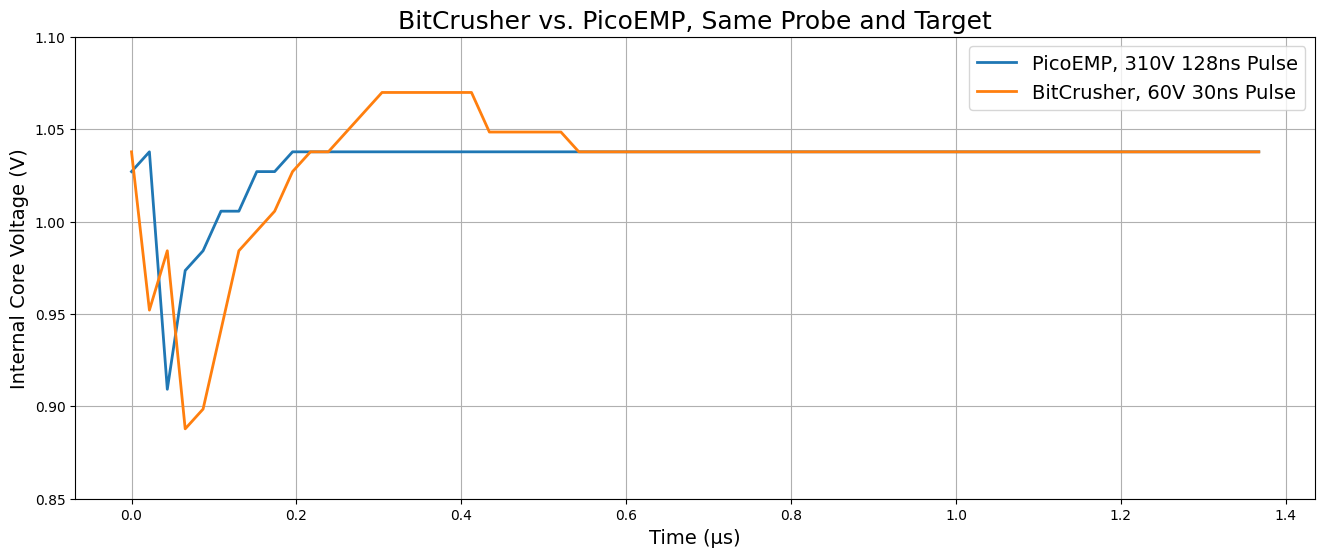

In [12]:
bitcrusher_trace = np.load("results/rev_1_tests/25mhz_tdc_bitcrusher_2026-03-26 11:22:58.npy")
picoemp_trace = np.load("results/rev_1_tests/25mhz_tdc_picoemp_16pl_pltdata.npy")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16 ,6), sharex=True)
yrange = [0.85, 1.1]
ax.set_ylim(yrange)

ax.set_title("BitCrusher vs. PicoEMP, Same Probe and Target", fontsize=18)
ax.set_ylabel("Internal Core Voltage (V)", fontsize=14)
ax.set_xlabel("Time (\u03BCs)", fontsize=14)
ax.grid(True)

x = np.arange(0, bitcrusher_trace.shape[0]) * (1/(25e6*1.843))  # 64 samples
y = (a*bitcrusher_trace + b) / 1000.0
ax.plot(x*1e6, y, linewidth=2)

x_shift = -18  # samples to shift
x = np.arange(0, picoemp_trace.shape[0]) * (1/(25e6*1.843))
y = (a*picoemp_trace + b) / 1000.0
y[0:y.shape[0]-abs(x_shift)] = y[abs(x_shift):]
ax.plot(x*1e6, y, linewidth=2)

ax.legend(["PicoEMP, 310V 128ns Pulse", "BitCrusher, 60V 30ns Pulse"], fontsize=14)

plt.savefig(plots_dir + "/Figure-BC-vs-PE-pulse.png", bbox_inches="tight", dpi=900)
plt.show()
